In [22]:
import pandas as pd
import numpy as np
import pycountry_convert as pc
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, 
                             r2_score, 
                             mean_absolute_error,
                             accuracy_score, 
                             classification_report,
                             confusion_matrix)
from sklearn.model_selection import (train_test_split,
                                     learning_curve,
                                     cross_val_score, 
                                     validation_curve, 
                                     GridSearchCV)
from sklearn.preprocessing import OneHotEncoder , StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


import warnings 
warnings.filterwarnings("ignore")

# EDA

In [2]:
df = pd.read_csv("Fifa.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [3]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [4]:
# NUmber of missing values in each column   
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [5]:
# see thw skwness of the data
print("Skewness of the data is : \n", df.skew(numeric_only=True))

Skewness of the data is : 
 Age                  0.968434
Overall_Rating       0.349970
Future Potential     0.038119
Value Per M$         7.983215
Total_Stats Score   -0.471524
dtype: float64


the skwenss of the Value per M$ is `Right Skew` with a skewness value of `7.98`

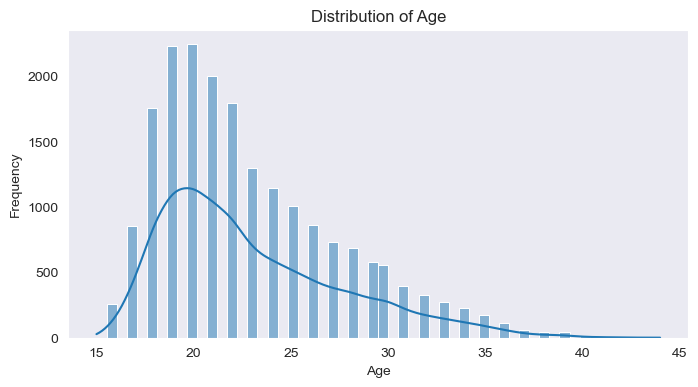

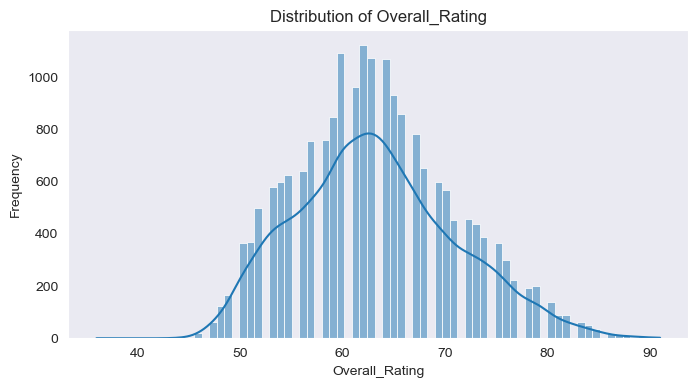

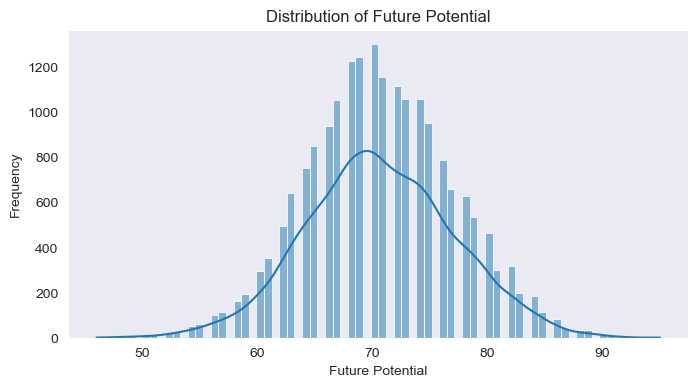

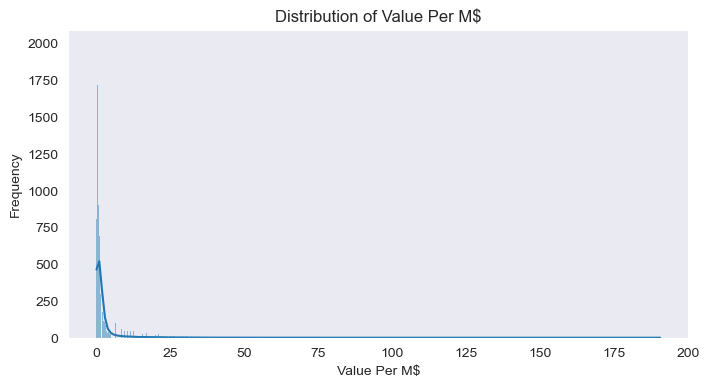

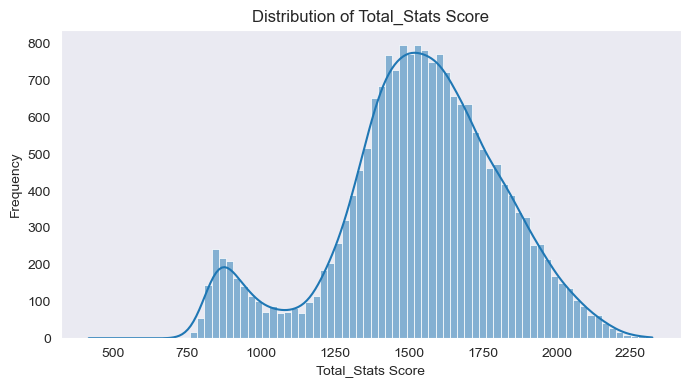

In [10]:
# plot the distribution of the data with dark theme
sns.set_style("dark")

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [11]:
# print the correlation between the numeric features and value per M$ sorted by the correlation value
correlation_matrix = df[numeric_cols].corr()
correlation_with_value_per_m = correlation_matrix["Value Per M$"].sort_values(ascending=False)
print("Correlation with Value per M$ : \n", correlation_with_value_per_m)

Correlation with Value per M$ : 
 Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


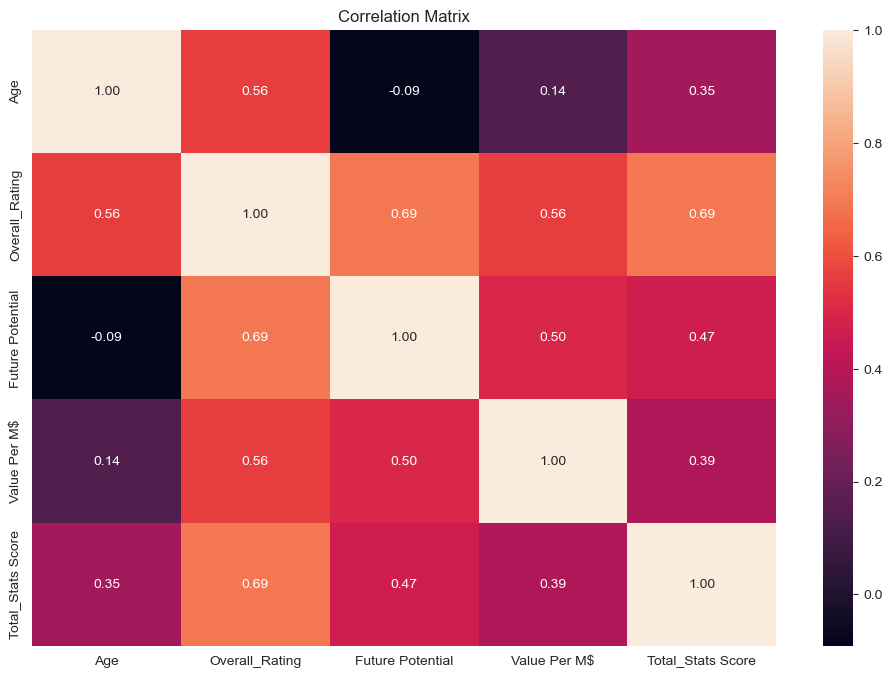

In [12]:
# correlation Matrix
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

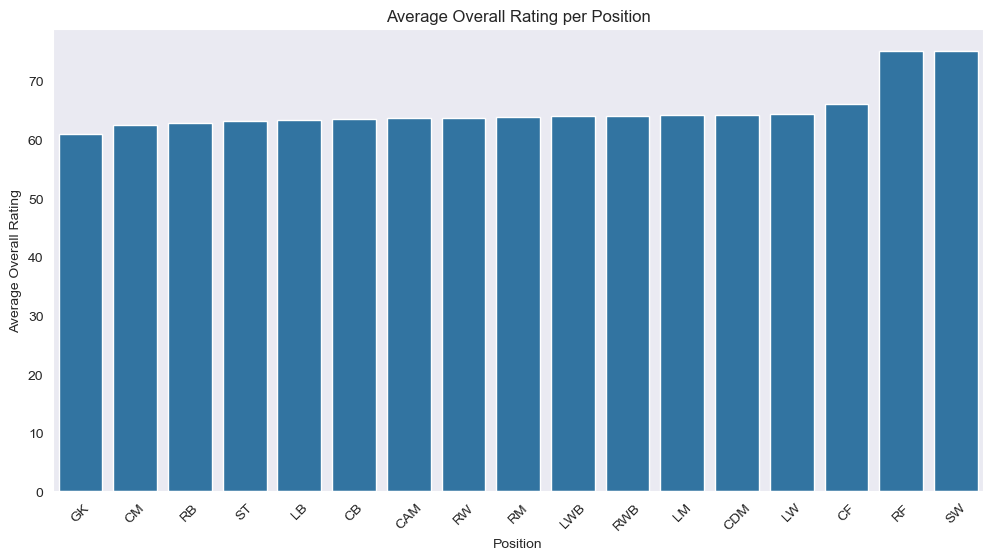

In [13]:
# plot average overall rating per position
average_overall_rating = df.groupby("Position")["Overall_Rating"].mean().reset_index().sort_values(by="Overall_Rating")
plt.figure(figsize=(12, 6))
sns.barplot(x="Position", y="Overall_Rating", data=average_overall_rating)
plt.title("Average Overall Rating per Position")
plt.xlabel("Position")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=45)
plt.show()

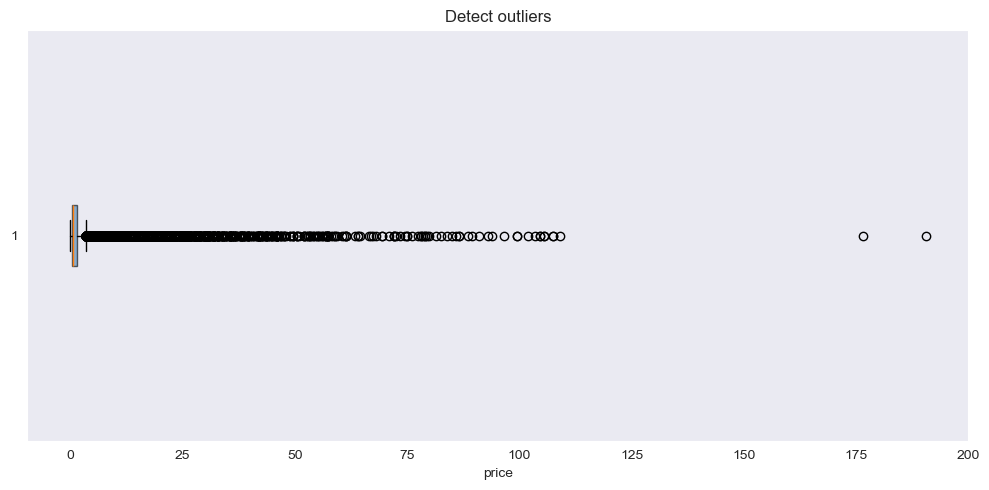

In [16]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['Value Per M$'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Detect outliers')
plt.xlabel('price')
plt.tight_layout()
plt.show()

# Preprocessing

In [2]:
def preprocess_data(df):
    df = df.drop(columns=["Name"])
    
    train, test = train_test_split(df, test_size=0.2, random_state=1)

    target_cols = ["Value Per M$"]
    train[target_cols] = np.log1p(train[target_cols])
    test[target_cols]  = np.log1p(test[target_cols])
    
    team_stats = train.groupby('Team').agg({
        'Age': 'mean',
        'Future Potential': 'mean',
    })
    team_stats['Strength'] = 0.3 * team_stats['Age'] + 0.7 * team_stats['Future Potential']
    team_strength_map = team_stats['Strength'].to_dict()
    
    train['Team_Strength'] = train['Team'].map(team_strength_map)
    test['Team_Strength']  = test['Team'].map(team_strength_map)
    
    train_mean = train['Team_Strength'].mean()
    train['Team_Strength'] = train['Team_Strength'].fillna(train_mean)
    test['Team_Strength']  = test['Team_Strength'].fillna(train_mean)
    
    train = train.drop(columns=['Team'])
    test  = test.drop(columns=['Team'])
    
    y_train = train[target_cols]
    y_test  = test[target_cols]
    train   = train.drop(columns=target_cols)
    test    = test.drop(columns=target_cols)

    def country_to_continent(country_name):
        try:
            country_code = pc.country_name_to_country_alpha2(country_name)
            continent_code = pc.country_alpha2_to_continent_code(country_code)
            return continent_code
        except:
            return 'Unknown'

    for d in [train, test]:
        d['Continent'] = d['Country'].apply(country_to_continent)
    
    continent_names = {'AF': 'Africa', 'AN': 'Antarctica', 'AS': 'Asia', 'EU': 'Europe', 'NA': 'North America', 'SA': 'South America'}
    for d in [train, test]:
        d['Continent_Name'] = d['Continent'].map(continent_names)
        d.drop(columns=["Country", "Continent"], inplace=True)
    
    categorical_cols = train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    
    numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
    
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
    
    if len(categorical_cols) > 0:
        train_enc = ohe.fit_transform(train[categorical_cols])
        test_enc  = ohe.transform(test[categorical_cols])
        train = pd.concat([train[numeric_cols], train_enc], axis=1)
        test  = pd.concat([test[numeric_cols],  test_enc],  axis=1)
    else:
        train = train[numeric_cols]
        test  = test[numeric_cols]
    
    scaler = StandardScaler()
    train_idx, test_idx = train.index, test.index
    train = pd.DataFrame(scaler.fit_transform(train), index=train_idx, columns=train.columns)
    test  = pd.DataFrame(scaler.transform(test),       index=test_idx,  columns=test.columns)
    
    q1 = train['Overall_Rating'].quantile(0.25)
    q2 = train['Overall_Rating'].quantile(0.50)
    q3 = train['Overall_Rating'].quantile(0.75)

    def performance_category(x):
        if x <= q1:
            return "Low"
        elif x <= q2:
            return "Medium"
        elif x <= q3:
            return "High"
        else:
            return "Elite"
    train_cf = train.copy()
    test_cf  = test.copy()

    train_cf['Performance_Class'] = train_cf['Overall_Rating'].apply(performance_category)
    test_cf['Performance_Class'] = test_cf['Overall_Rating'].apply(performance_category)
    
    train_cf = train_cf.drop(columns=['Overall_Rating'])
    test_cf  = test_cf.drop(columns=['Overall_Rating'])
    
    test = test[train.columns]

    return train, y_train, test, y_test, train_cf, test_cf

In [3]:
df = pd.read_csv("Fifa.csv")
x_train, y_train, x_test, y_test, train_cf, test_cf = preprocess_data(df)

In [4]:
x_train.head()

,Age,Overall_Rating,Future Potential,Total_Stats Score,Team_Strength,Position_CAM,Position_CB,Position_CDM,Position_CF,Position_CM,...,Position_RW,Position_RWB,Position_ST,Position_SW,Continent_Name_Africa,Continent_Name_Asia,Continent_Name_Europe,Continent_Name_North America,Continent_Name_South America,Continent_Name_nan
15046,0.855365,0.862960,0.205513,0.023718,-1.326604,-0.239872,2.362222,-0.271082,-0.118261,-0.385981,...,-0.191758,-0.124199,-0.401381,-0.007973,-0.265089,-0.275647,1.190114,-0.221058,-0.541081,-0.463476
15914,-0.211840,-0.413969,-0.256833,-0.071538,-0.223606,-0.239872,-0.423330,-0.271082,-0.118261,-0.385981,...,-0.191758,-0.124199,-0.401381,-0.007973,-0.265089,-0.275647,1.190114,-0.221058,-0.541081,-0.463476
18918,-0.425281,-0.158583,-0.102717,-0.420810,-1.307048,-0.239872,-0.423330,-0.271082,-0.118261,-0.385981,...,-0.191758,-0.124199,-0.401381,-0.007973,-0.265089,-0.275647,-0.840255,-0.221058,1.848151,-0.463476
18080,0.001601,-0.669355,-0.873294,-2.445882,-0.600692,-0.239872,-0.423330,-0.271082,-0.118261,-0.385981,...,-0.191758,-0.124199,-0.401381,-0.007973,-0.265089,-0.275647,1.190114,-0.221058,-0.541081,-0.463476
951,-0.425281,0.990652,2.209013,0.570558,0.959238,-0.239872,-0.423330,-0.271082,-0.118261,-0.385981,...,-0.191758,-0.124199,-0.401381,-0.007973,-0.265089,-0.275647,1.190114,-0.221058,-0.541081,-0.463476


<Axes: >

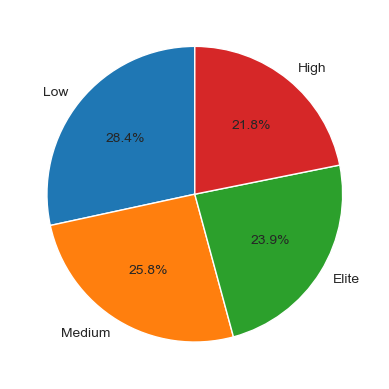

In [19]:
train_cf['Performance_Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ylabel=''
)

# Model Selection and justification

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [6]:
rows, cols = df.shape
print(f"Dataset has {rows} rows and {cols} columns.")

Dataset has 19667 rows and 9 columns.


In [7]:
skewness = df.skew(numeric_only=True)

high_skew = skewness[abs(skewness) > 1]

print("Highly Skewed Features:")
print(high_skew)


Highly Skewed Features:
Value Per M$    7.983215
dtype: float64


In [8]:
corr_matrix = df.select_dtypes(include=np.number).corr()

avg_corr = corr_matrix.abs().mean().mean()

print(f"Average Correlation Strength: {avg_corr:.2f}")

Average Correlation Strength: 0.55


In [9]:
num_features = len(df.select_dtypes(include=np.number).columns)

print(f"Number of Numerical Features: {num_features}")

Number of Numerical Features: 5


Medium data set and high skewness and categorical features indicate that `random forest` would be a good choice for this problem.

Low Correlation between features and slightly small number of numerical features also support choice of `SVM` Regressor with RBF kernel, which can capture non-linear relationships without needing many features.

Medium , numerical Features with low correlation and high skewness could also be good for `KNN` Regressor, which can capture local patterns in the data, also because players naturally form similarity clusters . 

# Implementation

In [7]:
def evaluate_regression(model, x_test, y_test, model_name="Model"):
    y_pred = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"  {model_name} - Regression Results")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*40}\n")

### LINEAR REGRESSION

In [28]:
baseline = LinearRegression()
baseline.fit(x_train, y_train)
 
y_train_pred_base = baseline.predict(x_train)
y_test_pred_base  = baseline.predict(x_test)

evaluate_regression(baseline, x_test, y_test, model_name="Baseline Linear Regression")


  Baseline Linear Regression - Regression Results
  RMSE : 0.3276
  MAE  : 0.2280
  R²   : 0.8023



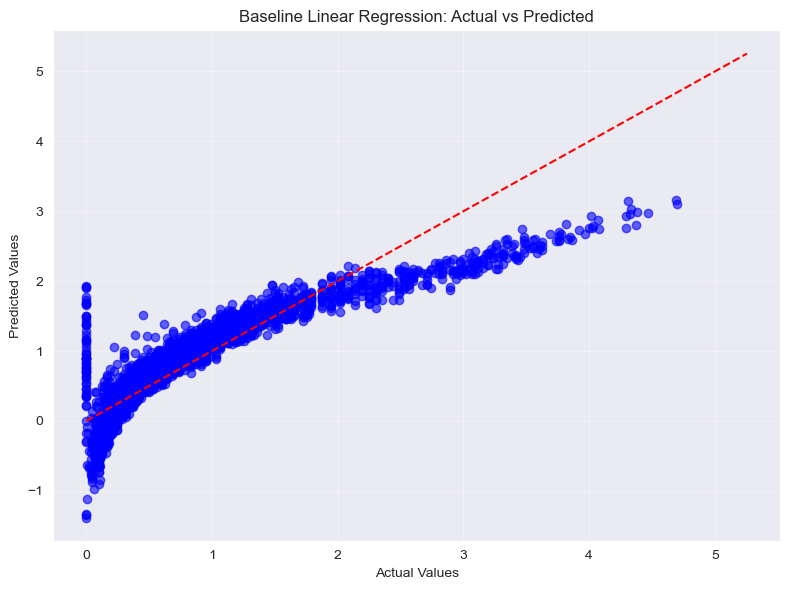

In [29]:
# plot actual vs predicted values for the test set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_base, alpha=0.6, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Baseline Linear Regression: Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Polynomial Regression

POLYNOMIAL REGRESSION

Degree: 1
  Polynomial Degree 1 - Regression Results
  RMSE : 0.3276
  MAE  : 0.2280
  R²   : 0.8023

  Train/Test Gap (R²)              0.0025

Degree: 2
  Polynomial Degree 2 - Regression Results
  RMSE : 0.1593
  MAE  : 0.0844
  R²   : 0.9533

  Train/Test Gap (R²)              0.0045

Degree: 3
  Polynomial Degree 3 - Regression Results
  RMSE : 0.1766
  MAE  : 0.0812
  R²   : 0.9425

  Train/Test Gap (R²)              0.0189


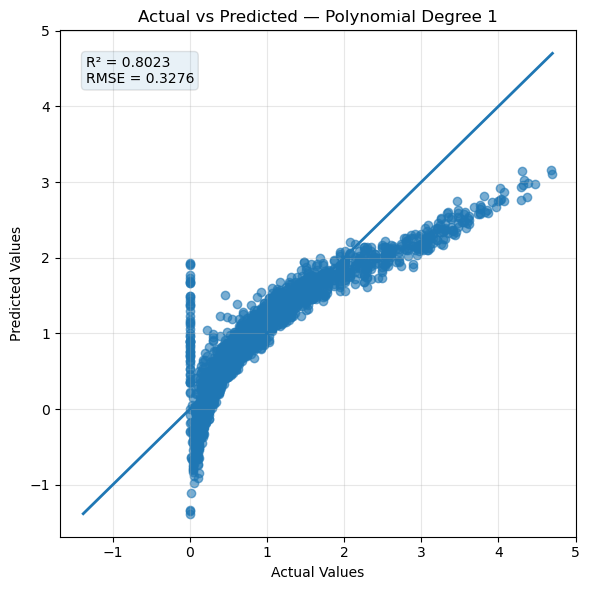

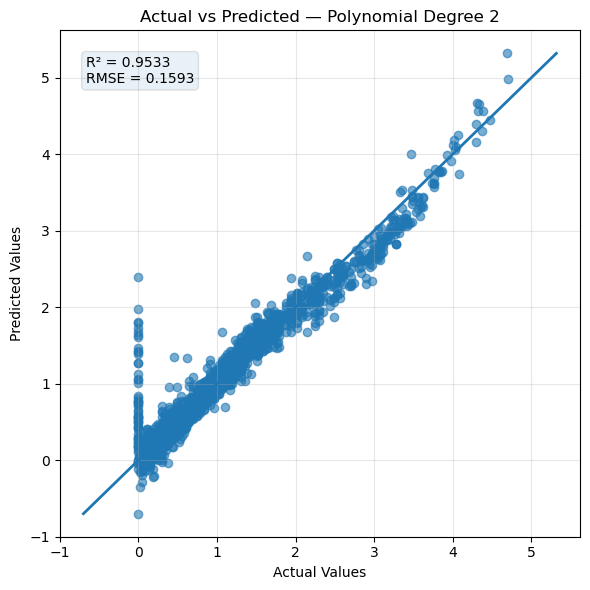

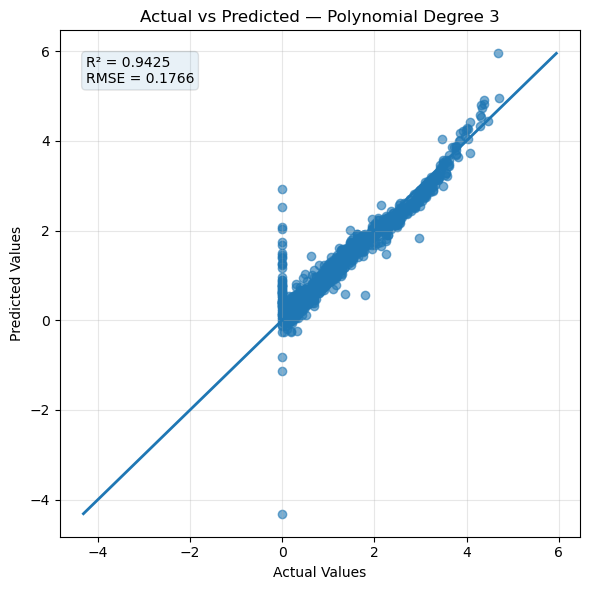

In [9]:
degrees       = [1, 2, 3]
train_r2_list = []
test_r2_list  = []
 
print("=" * 55)
print("POLYNOMIAL REGRESSION")
print("=" * 55)
 
for degree in degrees:
    # Expand numerical features only
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(x_train)
    X_test_poly  = poly.transform(x_test)
 
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
  
    y_train_pred = model.predict(X_train_poly)
    y_test_pred  = model.predict(X_test_poly)
 
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test,  y_test_pred)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)
 
    print(f"\nDegree: {degree}")
    evaluate_regression(model, X_test_poly, y_test, model_name=f"Polynomial Degree {degree}")
    print(f"  {'Train/Test Gap (R²)':<28} {abs(train_r2 - test_r2):>10.4f}")
 




for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(x_train)
    X_test_poly  = poly.transform(x_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict on test set
    y_test_pred = model.predict(X_test_poly)

    # Plot Actual vs Predicted
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.6)

    y_test_arr = np.asarray(y_test).ravel()
    y_pred_arr = np.asarray(y_test_pred).ravel()
    min_val = min(y_test_arr.min(), y_pred_arr.min())
    max_val = max(y_test_arr.max(), y_pred_arr.max())


    plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted — Polynomial Degree {degree}")

    # Optional metrics in title area
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    plt.text(
        0.05, 0.95,
        f"R² = {r2:.4f}\nRMSE = {rmse:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.1)
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

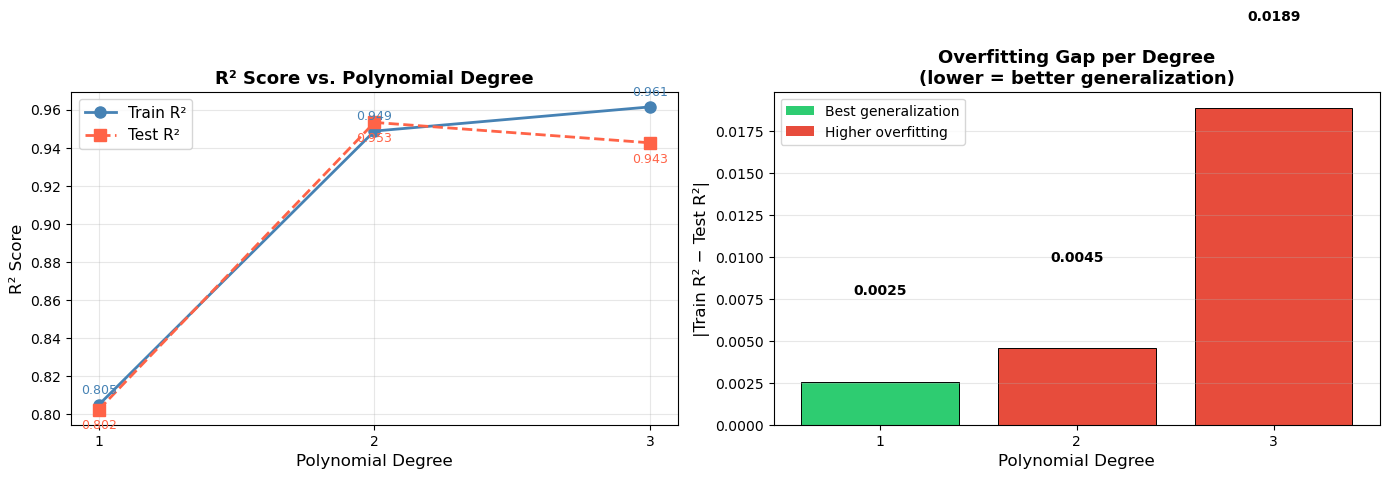


Plot saved as 'polynomial_degree_performance.png'


In [10]:
# ──────────────────────────────────────────────
# 3. PLOT: Degree vs. Train R² and Test R²
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# — Left: Line plot of R² vs Degree —
ax = axes[0]
ax.plot(degrees, train_r2_list, 'o-', color='steelblue',  linewidth=2, markersize=8, label='Train R²')
ax.plot(degrees, test_r2_list,  's--', color='tomato',    linewidth=2, markersize=8, label='Test R²')
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('R² Score',          fontsize=12)
ax.set_title('R² Score vs. Polynomial Degree', fontsize=13, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
 
# Annotate each point
for d, tr, te in zip(degrees, train_r2_list, test_r2_list):
    ax.annotate(f'{tr:.3f}', (d, tr), textcoords="offset points", xytext=(0,  8), ha='center', color='steelblue', fontsize=9)
    ax.annotate(f'{te:.3f}', (d, te), textcoords="offset points", xytext=(0, -14), ha='center', color='tomato',    fontsize=9)
 
# — Right: Bar chart of Train/Test gap —
gaps = [abs(tr - te) for tr, te in zip(train_r2_list, test_r2_list)]
bar_colors = ['#2ecc71' if g == min(gaps) else '#e74c3c' for g in gaps]
 
ax2 = axes[1]
bars = ax2.bar([str(d) for d in degrees], gaps, color=bar_colors, edgecolor='black', linewidth=0.7)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('|Train R² − Test R²|', fontsize=12)
ax2.set_title('Overfitting Gap per Degree\n(lower = better generalization)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
 
for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{gap:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
# Legend for gap chart
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Best generalization'),
                   Patch(facecolor='#e74c3c', label='Higher overfitting')]
ax2.legend(handles=legend_elements, fontsize=10)
 
plt.tight_layout()
plt.savefig('polynomial_degree_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'polynomial_degree_performance.png'")
 

### Random Forest Regressor

In [11]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,           
    min_samples_split=8,      
    min_samples_leaf=4,      
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(x_train, y_train.values.ravel())
rf_reg_results = evaluate_regression(rf_reg, x_test, y_test.values.ravel(), "Random Forest Regressor")


  Random Forest Regressor - Regression Results
  RMSE : 0.2089
  MAE  : 0.1145
  R²   : 0.9196



In [12]:
param_grid = {
    'n_estimators': [100, 200, 795],
    'max_depth': [20, 40, 60],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}



grid_search_rf_reg = GridSearchCV(estimator=rf_reg, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_rf_reg.fit(x_train, y_train.values.ravel())
print(f"Best Hyperparameters: {grid_search_rf_reg.best_params_}")
best_rf_reg = grid_search_rf_reg.best_estimator_
best_rf_reg_results = evaluate_regression(best_rf_reg, x_test, y_test.values.ravel(), "Optimized Random Forest Regressor")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 795}
  Optimized Random Forest Regressor - Regression Results
  RMSE : 0.1469
  MAE  : 0.0449
  R²   : 0.9603



### SVR (RBF Kernel)

In [13]:
svr = SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale")
svr.fit(x_train, y_train.values.ravel())
svr_results = evaluate_regression(svr, x_test, y_test.values.ravel(), "SVR (RBF Kernel)")

  SVR (RBF Kernel) - Regression Results
  RMSE : 0.1558
  MAE  : 0.0729
  R²   : 0.9553



In [14]:
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.02 ,0.1,  1],
    'gamma': ['scale', 'auto']
}


grid_search_svr = GridSearchCV(estimator=svr, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_svr.fit(x_train, y_train.values.ravel())
print(f"Best Hyperparameters: {grid_search_svr.best_params_}")
best_svr = grid_search_svr.best_estimator_
best_svr_results = evaluate_regression(best_svr, x_test, y_test.values.ravel(), "Optimized SVR (RBF Kernel)")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters: {'C': 10, 'epsilon': 0.02, 'gamma': 'auto'}
  Optimized SVR (RBF Kernel) - Regression Results
  RMSE : 0.1549
  MAE  : 0.0608
  R²   : 0.9558



### KNN Regressor

In [6]:
knn_reg = KNeighborsRegressor(n_neighbors=7, weights="distance", metric="euclidean", n_jobs=1)
knn_reg.fit(x_train, y_train.values.ravel())
knn_results = evaluate_regression(knn_reg, x_test, y_test.values.ravel(), "KNN Regressor")

  KNN Regressor - Regression Results
  RMSE : 0.2251
  MAE  : 0.1102
  R²   : 0.9067



In [16]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(estimator=knn_reg, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_knn.fit(x_train, y_train.values.ravel())
print(f"Best Hyperparameters: {grid_search_knn.best_params_}")
best_knn = grid_search_knn.best_estimator_
best_knn_results = evaluate_regression(best_knn, x_test, y_test.values.ravel(), "Optimized KNN Regressor")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  Optimized KNN Regressor - Regression Results
  RMSE : 0.2151
  MAE  : 0.1013
  R²   : 0.9148



## Random Forest Classifier

In [18]:
y_train_cf = train_cf['Performance_Class']
y_test_cf  = test_cf['Performance_Class']
x_train_cf = train_cf.drop(columns=['Performance_Class'])
x_test_cf  = test_cf.drop(columns=['Performance_Class'])
 
def evaluate_classification(model, x_test, y_test, model_name="Classifier"):
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"  {model_name} - Classification Results")
    print(f"{'='*40}")
    print(f"  Accuracy : {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))


In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="log2",
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(x_train_cf, y_train_cf)
rf_clf_results = evaluate_classification(rf_clf, x_test_cf, y_test_cf, "Random Forest Classifier")

  Random Forest Classifier - Classification Results
  Accuracy : 0.8416
              precision    recall  f1-score   support

       Elite       0.93      0.93      0.93       932
        High       0.80      0.75      0.78       861
         Low       0.89      0.88      0.89      1101
      Medium       0.75      0.79      0.77      1040

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.84      0.84      0.84      3934



In [19]:
param_grid = {
    'n_estimators': [200, 795],
    'max_depth': [12, 38],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_rf_clf = GridSearchCV(
    estimator=rf_clf, 
    param_grid=param_grid, 
    cv=3, 
    n_jobs=-1,
    verbose=1
)

grid_search_rf_clf.fit(x_train_cf, y_train_cf)

print(f"Best Parameters: {grid_search_rf_clf.best_params_}")
best_rf_clf = grid_search_rf_clf.best_estimator_
best_rf_clf_results = evaluate_classification(best_rf_clf, x_test_cf, y_test_cf, "Optimized Random Forest Classifier")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 795}
  Optimized Random Forest Classifier - Classification Results
  Accuracy : 0.8564
              precision    recall  f1-score   support

       Elite       0.95      0.94      0.94       932
        High       0.82      0.78      0.80       861
         Low       0.90      0.90      0.90      1101
      Medium       0.77      0.80      0.78      1040

    accuracy                           0.86      3934
   macro avg       0.86      0.85      0.86      3934
weighted avg       0.86      0.86      0.86      3934



## KNN Classifier

In [20]:
knn_clf = KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="euclidean", n_jobs=-1)
knn_clf.fit(x_train_cf, y_train_cf)
knn_clf_results = evaluate_classification(knn_clf, x_test_cf, y_test_cf, "KNN Classifier")

  KNN Classifier - Classification Results
  Accuracy : 0.7677
              precision    recall  f1-score   support

       Elite       0.88      0.87      0.88       932
        High       0.66      0.69      0.68       861
         Low       0.84      0.85      0.85      1101
      Medium       0.67      0.65      0.66      1040

    accuracy                           0.77      3934
   macro avg       0.77      0.77      0.77      3934
weighted avg       0.77      0.77      0.77      3934



In [21]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn_clf = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_knn_clf.fit(x_train_cf, y_train_cf)
print(f"Best Parameters: {grid_search_knn_clf.best_params_}")
best_knn_clf = grid_search_knn_clf.best_estimator_
best_knn_clf_results = evaluate_classification(best_knn_clf, x_test_cf, y_test_cf, "Optimized KNN Classifier")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
  Optimized KNN Classifier - Classification Results
  Accuracy : 0.7867
              precision    recall  f1-score   support

       Elite       0.92      0.86      0.89       932
        High       0.70      0.73      0.71       861
         Low       0.85      0.84      0.85      1101
      Medium       0.69      0.70      0.70      1040

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.79      0.79      0.79      3934



### Logistic Regression Model

In [19]:
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(x_train_cf, y_train_cf)

# Make predictions
y_pred = logmodel.predict(x_test_cf)

evaluate_classification(logmodel, x_test_cf, y_test_cf, "Logistic Regression Classifier")

  Logistic Regression Classifier - Classification Results
  Accuracy : 0.8005
              precision    recall  f1-score   support

       Elite       0.89      0.87      0.88       932
        High       0.69      0.70      0.69       861
         Low       0.89      0.88      0.88      1101
      Medium       0.73      0.74      0.73      1040

    accuracy                           0.80      3934
   macro avg       0.80      0.80      0.80      3934
weighted avg       0.80      0.80      0.80      3934



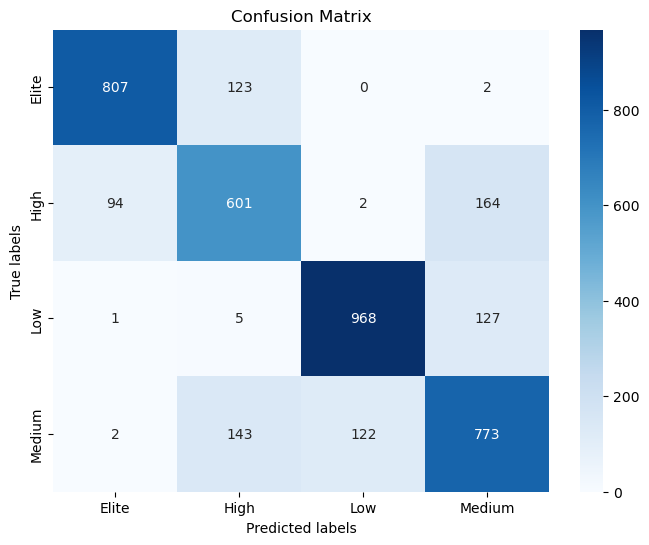

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test_cf, y_pred)
labels = logmodel.classes_

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='g',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Error Diagnosis

In [22]:
def diagnose_bias_variance(model, X_train, y_train, X_test, y_test, model_name="Model"):

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    gap = test_rmse - train_rmse

    relative_gap = gap / test_rmse

    if train_r2 < 0.75 and test_r2 < 0.75:
        diagnosis = "Underfitting"

    elif relative_gap > 0.30:
        diagnosis = "Strong Overfitting"

    elif relative_gap > 0.15:
        diagnosis = "Mild Overfitting"

    elif relative_gap <= 0.15 and test_r2 >= 0.85:
        diagnosis = "Good Fit"

    else:
        diagnosis = "Fit with Moderate Bias and Variance"

    print(f"{'='*60}")
    print(f"  Bias-Variance Diagnosis: {model_name}")
    print(f"{'='*60}")
    print(f"  Train RMSE : {train_rmse:.4f}   |  Test RMSE : {test_rmse:.4f}")
    print(f"  Train R²   : {train_r2:.4f}   |  Test R²   : {test_r2:.4f}")
    print(f"  Gap (RMSE)                     : {gap:.4f}")
    print(f"  Relative Gap                   : {relative_gap:.2%}")
    print(f"  Diagnosis                      : {diagnosis}")
    print(f"{'='*60}\n")

    return {
        "model": model_name,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "gap": gap,
        "relative_gap": relative_gap,
        "diagnosis": diagnosis
    }

In [23]:
diagnose_rf_reg = diagnose_bias_variance(best_rf_reg, x_train, y_train.values.ravel(), x_test, y_test.values.ravel(), "Random Forest Regressor")

  Bias-Variance Diagnosis: Random Forest Regressor
  Train RMSE : 0.0912   |  Test RMSE : 0.1469
  Train R²   : 0.9855   |  Test R²   : 0.9603
  Gap (RMSE)                     : 0.0556
  Relative Gap                   : 37.88%
  Diagnosis                      : Strong Overfitting



In [24]:
diagnose_svr = diagnose_bias_variance(best_svr, x_train, y_train.values.ravel(), x_test, y_test.values.ravel(), "SVR (RBF Kernel)")

  Bias-Variance Diagnosis: SVR (RBF Kernel)
  Train RMSE : 0.1482   |  Test RMSE : 0.1549
  Train R²   : 0.9616   |  Test R²   : 0.9558
  Gap (RMSE)                     : 0.0067
  Relative Gap                   : 4.33%
  Diagnosis                      : Good Fit



In [25]:
diagnose_knn = diagnose_bias_variance(best_knn, x_train, y_train.values.ravel(), x_test, y_test.values.ravel(), "KNN Regressor")

  Bias-Variance Diagnosis: KNN Regressor
  Train RMSE : 0.0000   |  Test RMSE : 0.2151
  Train R²   : 1.0000   |  Test R²   : 0.9148
  Gap (RMSE)                     : 0.2151
  Relative Gap                   : 100.00%
  Diagnosis                      : Strong Overfitting



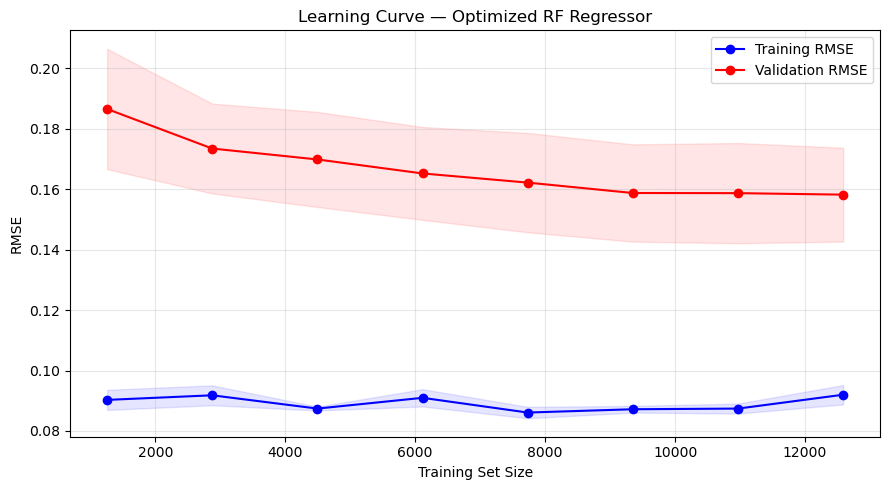

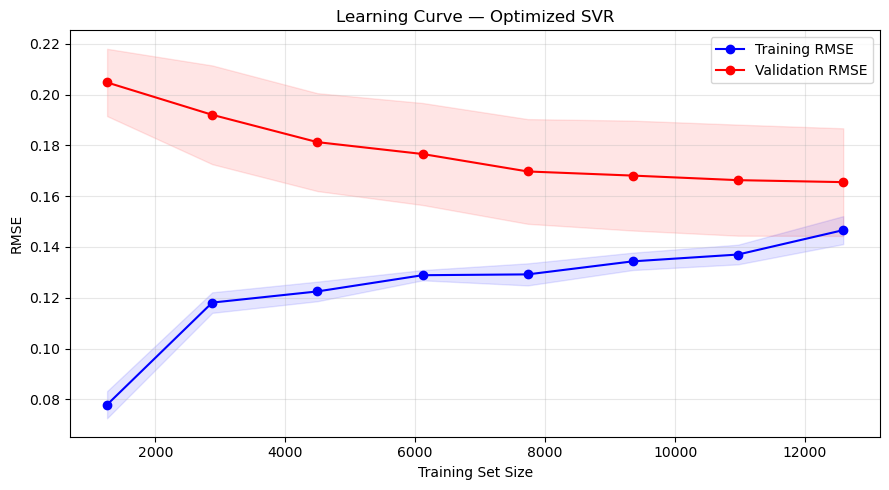

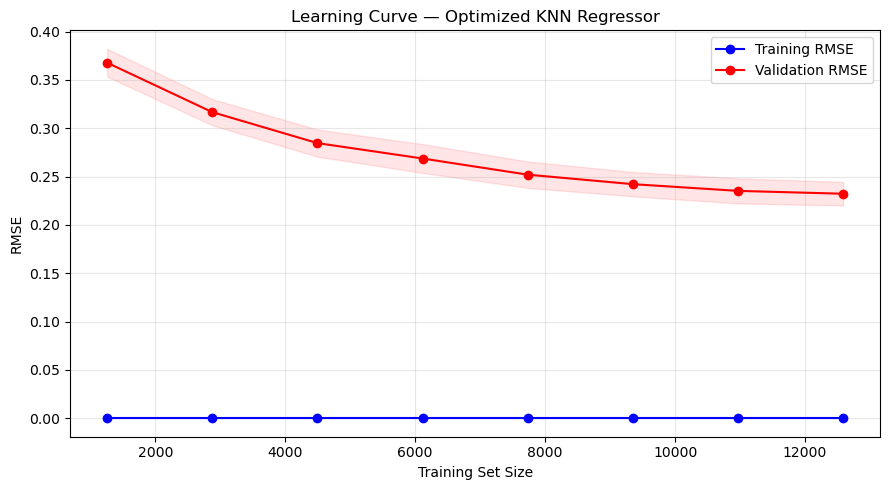

In [26]:
def plot_learning_curve(model, X, y, model_name, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    train_mean = -np.mean(train_scores, axis=1)
    val_mean   = -np.mean(val_scores, axis=1)
    train_std  = -np.std(train_scores, axis=1)
    val_std    = -np.std(val_scores, axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training RMSE')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation RMSE')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(f"Learning Curve — {model_name}")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_learning_curve(best_rf_reg, x_train, y_train.values.ravel(), "Optimized RF Regressor")
plot_learning_curve(best_svr, x_train, y_train.values.ravel(), "Optimized SVR")
plot_learning_curve(best_knn, x_train, y_train.values.ravel(), "Optimized KNN Regressor")

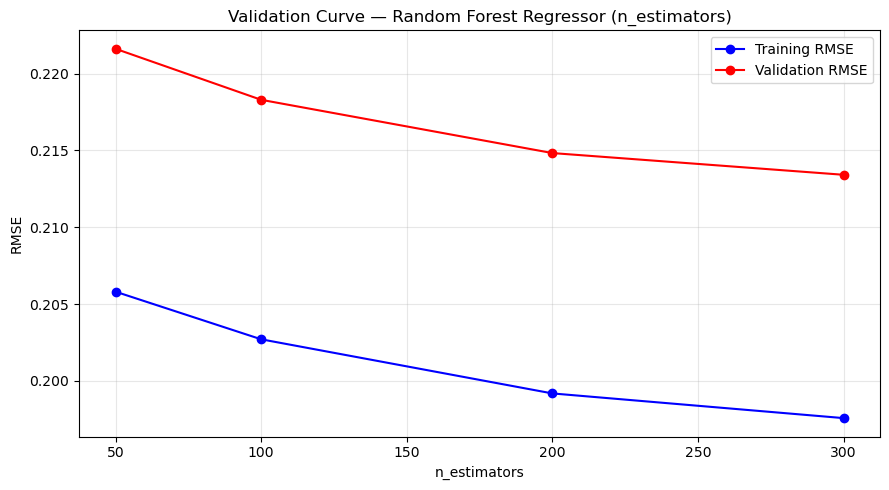

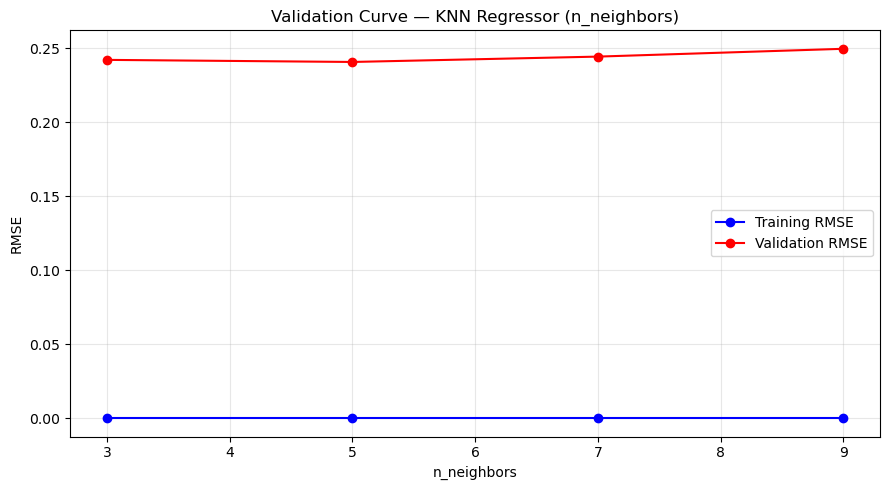

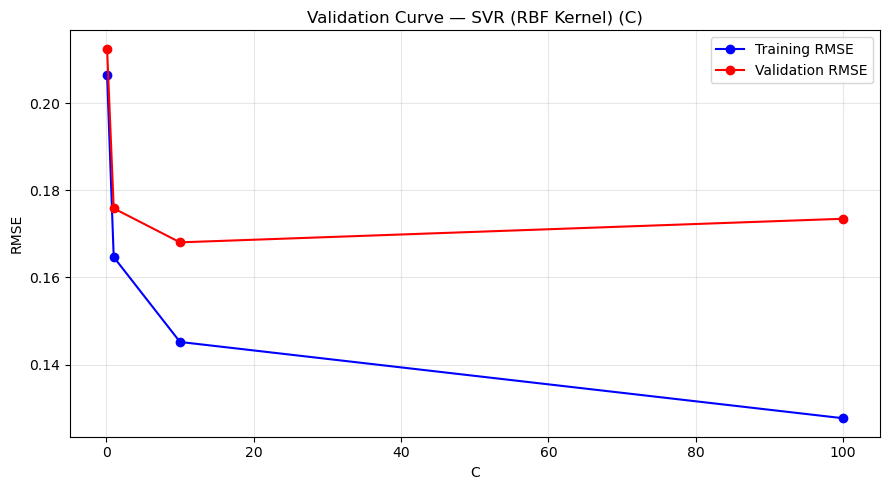

In [27]:
def plot_validation_curve(model, X, y, param_name, param_range, model_name, cv=5):
    train_scores, val_scores = validation_curve(
        model, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    train_mean = -np.mean(train_scores, axis=1)
    val_mean   = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(param_range, train_mean, 'o-', color='blue', label='Training RMSE')
    plt.plot(param_range, val_mean, 'o-', color='red', label='Validation RMSE')
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.title(f"Validation Curve — {model_name} ({param_name})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_validation_curve(rf_reg, x_train, y_train.values.ravel(), 'n_estimators', [50, 100, 200, 300], "Random Forest Regressor")
plot_validation_curve(knn_reg, x_train, y_train.values.ravel(), 'n_neighbors', [3, 5, 7, 9], "KNN Regressor")
plot_validation_curve(svr, x_train, y_train.values.ravel(), 'C', [0.1, 1, 10, 100], "SVR (RBF Kernel)")

In [28]:
def cv_stability_check(model, X, y, model_name, cv=10):
    scores = cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    print(f"{'='*50}")
    print(f"  CV Stability: {model_name}")
    print(f"{'='*50}")
    print(f"  Mean R²  : {scores.mean():.4f}")
    print(f"  Std R²   : {scores.std():.4f}")
    print(f"  Min R²   : {scores.min():.4f}")
    print(f"  Max R²   : {scores.max():.4f}")
    if scores.std() > 0.05:
        print(f"   likely OVERFITTING")
    elif scores.mean() < 0.70:
        print(f"   Low mean R² likely UNDERFITTING")
    else:
        print(f"  Stable and strong generalization")
    print(f"{'='*50}\n")
    return {"model": model_name, "cv_mean_r2": scores.mean(), "cv_std_r2": scores.std()}

cv_rf  = cv_stability_check(best_rf_reg, x_train, y_train.values.ravel(), "Optimized RF")
cv_knn = cv_stability_check(best_knn, x_train, y_train.values.ravel(), "Optimized KNN")
cv_svr = cv_stability_check(best_svr, x_train, y_train.values.ravel(), "Optimized SVR")

  CV Stability: Optimized RF
  Mean R²  : 0.9563
  Std R²   : 0.0153
  Min R²   : 0.9182
  Max R²   : 0.9778
  Stable and strong generalization

  CV Stability: Optimized KNN
  Mean R²  : 0.9109
  Std R²   : 0.0145
  Min R²   : 0.8747
  Max R²   : 0.9310
  Stable and strong generalization

  CV Stability: Optimized SVR
  Mean R²  : 0.9521
  Std R²   : 0.0176
  Min R²   : 0.9058
  Max R²   : 0.9740
  Stable and strong generalization



# Ensemble

In [29]:
from sklearn.ensemble import VotingRegressor

ensemble_reg = VotingRegressor([
    ('rf', best_rf_reg),
    ('svr', best_svr),
    ('knn', best_knn)
])

ensemble_reg.fit(
    x_train,
    y_train.values.ravel()
)
y_pred_ensemble = ensemble_reg.predict(x_test)
ensemble_results = evaluate_regression(
    ensemble_reg,
    x_test,
    y_test.values.ravel(),
    "Voting Regressor Ensemble"
)

  Voting Regressor Ensemble - Regression Results
  RMSE : 0.1525
  MAE  : 0.0572
  R²   : 0.9572



In [30]:
comparison_df = pd.DataFrame([
    best_rf_reg_results,
    best_svr_results,
    best_knn_results,
    ensemble_results
])

comparison_df

,model,RMSE,MAE,R2
0,Optimized Random Forest Regressor,0.146855,0.044898,0.960273
1,Optimized SVR (RBF Kernel),0.154949,0.060839,0.955773
2,Optimized KNN Regressor,0.215119,0.101276,0.914757
3,Voting Regressor Ensemble,0.152457,0.057229,0.957185


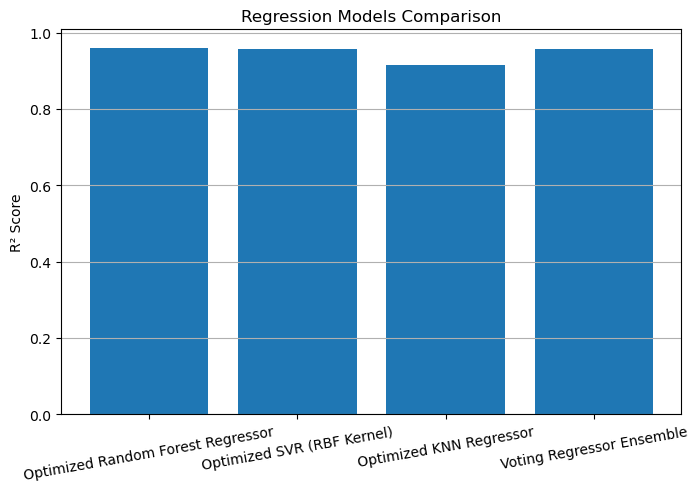

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['model'],
    comparison_df['R2']
)

plt.title('Regression Models Comparison')
plt.ylabel('R² Score')

plt.xticks(rotation=10)

plt.grid(axis='y')

plt.show()